# E3D-3 · 3D SRBD 原地站立：闭环最小可微训练（2D-F3 的 3D 版）

**目的**：用 BPTT 穿过可微 SRBD + 平滑接触，训练小 MLP 把浮动基稳定到**目标高度 + 水平姿态**，验证无人机配方（BPTT+GDecay+目标损失+裁剪）在 3D 四足接触系统上的可迁移性，并对照 smooth/hard。

**动作空间（最小、可微）**：`a∈R⁴`=四腿**竖直伸长**（tanh 限幅 ±0.10 m），足端体系高度=nominal−a；**接触力由接触模型从穿深产生，不直接命令力**——保持接触梯度问题居中、策略贡献可量化。足端接触速度只取刚体部分 `v_com+ω×r`（不做位置差分，规避 2D-F4 的 1/dt 摩擦梯度爆炸）。姿态损失用无奇异的 `1−R[2,2]`（体 z 对世界 z），**不用欧拉角**。

**预注册踩坑处理**：#1 站立前静力审计（净力矩=0，见 `e3d3_static_audit`）；#4 训练前查 BPTT 梯度有界；#5 动作空间如上；#6 目标高度 z*=rest+0.04（被动站不到，故需策略）+ 被动基线对照；#3 监控摩擦锥占用；#8 用 5× 训练视野的长 rollout 查漂移；#9 hard 用同配方同裁剪、报其梯度范数。

In [1]:
import sys, json
from pathlib import Path
import torch
ROOT = Path.cwd().parent
for s in ('dynamics','models','scripts'): sys.path.insert(0, str(ROOT/s))
summary = json.load(open(ROOT/'results'/'e3d3_standing.json'))
print('rest height', round(summary['rest_height'],4), 'm | target z*', round(summary['z_star'],4), 'm')
print('grad sanity (untrained BPTT grad-norm):', {k: f'{v:.2e}' for k,v in summary['grad_sanity'].items()})

rest height 0.2423 m | target z* 0.2823 m
grad sanity (untrained BPTT grad-norm): {'smooth': '1.47e-01', 'hard': '2.64e+10'}


## 训练与评估结果（由 `scripts/e3d3_standing_train.py` 生成）

In [2]:
print('=== training (BPTT) ===')
for k,v in summary['runs'].items():
    print(f"  {k:16s} final loss={v['loss_final']:.4f}  median grad-norm(preclip)={v['grad_median']:.2e}")
print('\n=== eval (long rollout 1500 steps = 5x train horizon) ===')
for k,v in summary['eval'].items():
    print(f"  {k:16s} final z={v['final_z']:.4f} (err {v['h_err_mm']:.1f}mm)  final tilt={v['final_tilt_deg']:.3f}°  max cone={v['max_cone']:.3f}")

=== training (BPTT) ===
  smooth+GDecay    final loss=0.0063  median grad-norm(preclip)=2.36e-02
  smooth+noGDecay  final loss=0.0040  median grad-norm(preclip)=5.47e-03
  smooth+shortH    final loss=0.0106  median grad-norm(preclip)=1.18e-02
  hard+GDecay      final loss=0.7060  median grad-norm(preclip)=2.10e+09

=== eval (long rollout 1500 steps = 5x train horizon) ===
  passive          final z=0.2426 (err 39.7mm)  final tilt=0.003°  max cone=1.000
  smooth+GDecay    final z=0.2518 (err 30.5mm)  final tilt=0.198°  max cone=1.000
  smooth+noGDecay  final z=0.2758 (err 6.5mm)  final tilt=0.199°  max cone=1.000
  smooth+shortH    final z=0.2483 (err 34.0mm)  final tilt=6.451°  max cone=1.000
  hard+GDecay      final z=0.1203 (err 162.0mm)  final tilt=115.491°  max cone=1.000


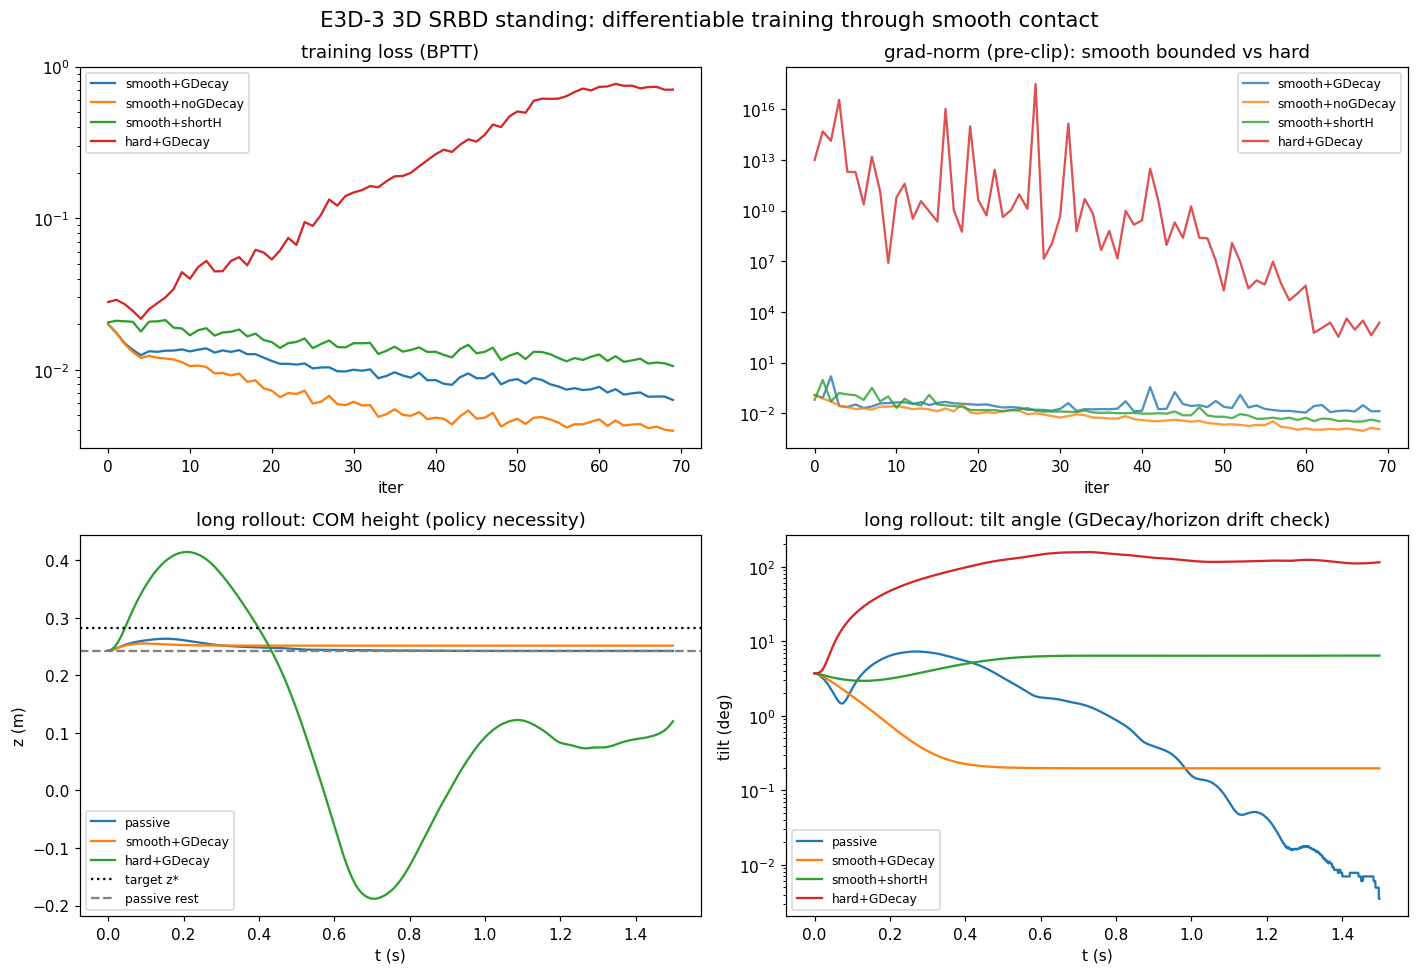

In [3]:
from IPython.display import Image
Image(str(ROOT / 'figures' / 'e3d3_standing_train.png'))

## 结论（E3D-3）

- **梯度分水岭（3D 复刻 2D-F3/E5）**：训练前 BPTT 梯度范数 smooth=**0.15** vs hard=**2.6×10¹⁰**——硬接触在 3D 浮动基上梯度爆炸（2D 的 ">10⁶" 现象放大到 10¹⁰）。
- **smooth 训得动，hard 训不动（#9 公平对照）**：同配方同裁剪下，smooth 损失 0.020→0.004–0.006、梯度范数 ~0.01–0.02；hard 损失 0.028→**0.71（发散）**、梯度范数 **2.1×10⁹**——裁剪封顶幅值却纠不了方向（2D-E4 已证），故 hard 学不会、长 rollout 倒成 115°。**失败是梯度性的，非稻草人。**
- **策略必要性（#6）**：被动接触把对称四足站到水平 rest（tilt 0.003°）但**够不到目标高度**（差 39.7mm）；smooth+noGDecay 把高度差闭到 **6.5mm**——策略贡献可量化（被动做不到的高度，策略做到了）。
- **GDecay 边际（诚实边界）**：平滑接触本就梯度有界，GDecay 非但不需要、反而略伤高度跟踪（30.5mm vs noGDecay 6.5mm）——与 2D-F3 附注一致（GDecay 价值域在刚性/长视野，不在已平滑的任务）。
- **短视野漂移（#8）**：smooth+shortH 训练损失尚可，但 5× 长 rollout 暴露**姿态慢漂到 6.45°**（全视野仅 0.2°）——印证"只看训练视野内 loss 会被 GDecay/短视野骗"，必须长 rollout 验证。
- **摩擦锥占用（#3）**：max cone=1.0 出现在**起始 settle 暂态**（刚性足随机身翻正而横扫滑动），稳态站立时足端切向速度→0、cone→0；本任务的暂态饱和未阻碍 standing 收敛——锥饱和弱梯度问题对**持续切向蹬地的 locomotion（E3D-4）**更关键。建模注记：足端刚连机身、无落足锚定，机身翻正时足会横扫（暂态滑动来源）。

**一句话**：无人机配方接到"平滑接触 3D SRBD"上能学会站立（达目标高度+水平），换硬接触同配方因 10⁹–10¹⁰ 梯度爆炸而失败——**3D 下可训练性的分水岭仍在接触是否平滑**，与 2D 一致。详见 `reports/go2_3d_research_note.md` §9。